In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tqdm import trange
import random


I = 8
K = 4
DEFAULT_N_ITEMS_BASKET = 5
N_BASKET = 20
TRAINING_EPOCHS = 20
TRAINING_BATCH_SIZE = 1000
L_R = 0.001
K_NOISE = 15



Wi = tf.Variable(tf.random.normal((K, I), stddev=0.1), name='Wi')
Wo = tf.Variable(tf.random.normal((I, K), stddev=0.1), name='Wo')
wa = tf.Variable(tf.random.normal((K,), stddev=0.1), name='wa')








In [2]:
class Items:
    def __init__(self, Wi, Wo, n_items = I, embedding_dim = K):
        self.n_items = n_items
        self.embedding_dim = embedding_dim
        self.input_embedding_Wi = Wi
        self.output_embedding_Wo  = Wo
        self.one_hots = tf.cast(tf.keras.utils.to_categorical(tf.range(self.n_items, dtype=tf.int64).numpy(),
                                                      num_classes=self.n_items), tf.float32)

    def __repr__(self):
        return f"Items(n_items={self.n_items}, embedding_dim={self.embedding_dim})"

    def update_embedding(self, new_Wi, new_Wo):
        self.input_embedding_Wi = new_Wi
        self.output_embedding_Wo = new_Wo

In [3]:
class Basket(Items):
    def __init__(self, Wi, Wo, n_items = I, embedding_dim= K, basket_items=None, n_items_basket=DEFAULT_N_ITEMS_BASKET):
        super().__init__(Wi, Wo, n_items, embedding_dim)
        if basket_items != None:
            self.basket_items = tf.convert_to_tensor(basket_items, dtype=tf.int32)
            self.n_items_basket = len(self.basket_items)
        else:
            self.basket_items = None
            self.n_items_basket = n_items_basket
        
        if self.basket_items == None:
            self._sample()
    
    def __repr__(self):
        return f"{self.basket_items.numpy()}"
  
    def _sample(self):
        indices = tf.range(self.n_items, dtype=tf.int64)
        shuffled = tf.random.shuffle(indices)
        sample = shuffled[:self.n_items_basket]
        self.basket_items= sample
        return sample
    
    def describe(self):
        print("Transaction:", self.basket_items.numpy())

    
    def update_embedding(self, new_Wi, new_Wo):
        super().update_embedding(new_Wi, new_Wo)

In [4]:
class Context:
    def __init__(self, basket, wa, target_item = None):
        self.Theta = [basket.input_embedding_Wi, 
                      wa, 
                      basket.output_embedding_Wo]
        self.basket = basket
        if target_item is None:
            target_item = random.choice(basket.basket_items.numpy())
        elif target_item not in basket.basket_items.numpy():
            raise ValueError("Target item must be part of the transaction items.")
        
        self.target_item = target_item
        self.context_items = tf.boolean_mask(self.basket.basket_items, self.basket.basket_items != target_item)
        self.context_embedding = None

    
    def __repr__(self):
        return f"context items ={self.context_items.numpy()}"
            

    def _context_embed(self):
        Wi, wa, Wo = self.Theta
        context_items_embeding = tf.gather(tf.tensordot(self.basket.input_embedding_Wi, self.basket.one_hots, axes=1), self.context_items, axis=1)
        e_h = tf.linalg.matvec(tf.transpose(context_items_embeding),wa) 
        exponents = tf.exp(e_h)
        alpha_weights = exponents / tf.reduce_sum(exponents)
        self.context_embedding = tf.tensordot(context_items_embeding,alpha_weights, axes=1)


    def score(self, item):
        Wi, wa, Wo = self.Theta
        self._context_embed()
        return tf.tensordot(Wo[item], self.context_embedding, axes=1)
    
    def most_relevant(self):
        scores = np.array([context.score(i) for i in range(I)])
        for i in context.context_items.numpy():
            scores[i] = -np.inf
        return np.argmax(scores)
    
    def describe(self):
        self._context_embed()
        print("Target item is", self.target_item," in the context:",self.context_items.numpy() )
        print("Context embedding shape:", self.context_embedding.shape)
        print("Target item score:", self.score(self.target_item).numpy())

    def update_embedding(self, new_Wi, new_Wo, new_wa):
        self.Theta[0] = new_Wi
        self.Theta[2] = new_Wo
        self.Theta[1] = new_wa
        self._context_embed()

In [5]:
class Trainer:
    def __init__(self, data, Theta, lr = L_R, K_noise = K_NOISE, epochs = TRAINING_EPOCHS):
        self.contexts_and_target_item = data
        self.all_items = self.contexts_and_target_item[0][0].basket.n_items
        self.Theta = Theta
        self.lr = lr
        self.K_noise = K_noise
        self.optimizer = tf.keras.optimizers.Adam(self.lr)
        self.epochs = epochs
        self.Q = [1.0 / (self.all_items-1) for _ in range(self.all_items)]


    def custom_loss(self, context, target_item):
        basket_items = context.basket.basket_items  
        all_items = tf.range(self.all_items, dtype=basket_items.dtype)
        mask = ~tf.reduce_any(tf.equal(all_items[:, None], basket_items[None, :]), axis=1)
        neg_pool = tf.boolean_mask(all_items, mask)
        neg_items = tf.random.shuffle(neg_pool)[:self.K_noise]
        KQ = self.K_noise * self.Q[target_item]
        def P_1_c(i_c):
            S = context.score(i_c)
            return tf.exp(3*S) / (tf.exp(3*S)+ KQ)
        def P_0_c(i_c):
            S = context.score(i_c)
            return 1 - (tf.exp(3*S) / (tf.exp(3*S)+ KQ))
        loss = -tf.math.log(P_1_c(target_item) + 1e-10)
        for i in neg_items:
            loss -= tf.math.log(P_0_c(i) + 1e-10)
        return loss

    def forward(self, context, target_item):
        return self.custom_loss(context, target_item)
    


    def fit(self, verbose = True, batch_size = TRAINING_BATCH_SIZE):
        loss_history = [float('inf')]*10
        n = len(self.contexts_and_target_item)
        #l2_lambda = 1e-4


        for epoch in trange(self.epochs, desc="Training epochs"):
            self.contexts_and_target_item[0][0].basket.update_embedding(self.Theta[0], self.Theta[2])
            batch = random.sample(self.contexts_and_target_item, min(batch_size, n))

            with tf.GradientTape() as tape:
                total_loss = 0.0
                for ctx, target_item in batch:
                    ctx.update_embedding(self.Theta[0], self.Theta[2], self.Theta[1])
                    ctx._context_embed()
                    loss = self.forward(ctx, target_item)
                    total_loss += loss
                #total_loss = total_loss / len(self.contexts_and_target_item)
                #if total_loss > 2*min(loss_history[-10:]):
                #    continue
                #total_loss += l2_lambda * (tf.reduce_sum(tf.square(self.Theta[0])) + 
                #                           tf.reduce_sum(tf.square(self.Theta[1])) + 
                #                           tf.reduce_sum(tf.square(self.Theta[2])))
            Wi, wa, Wo = self.Theta
            grads = tape.gradient(total_loss, [Wi, wa, Wo])
            self.optimizer.apply_gradients(zip(grads, [Wi, wa, Wo]))
            loss_history.append(total_loss.numpy())
            #if verbose and epoch % 50 == 0:
                ##print(f"Epoch {epoch}, Loss: {total_loss.numpy():.4f}")

  
        return loss_history


In [6]:
# Constants for data generation
PROBA_COMPLEMENTARY_ITEMS = 0.7
PROBA_NEUTRAL_ITEMS = 0.3
DICT_ITEMS_CLASSES = {
    "nest0": ({0,1,2}, [-1, 1, 0, 0]) ,
    "nest1": ({3,4,5}, [1, -1, 0, 0]),
    "nest2": ({6}, [0, 0, -1, 0]),
    "nest3": ({7}, [0, 0, 0, -1])
}

ASSORTMENT = {0, 1, 2, 3, 4, 5, 6, 7}
AVAILABLE_SETS = list(KEY for KEY, VALUE in DICT_ITEMS_CLASSES.items() if VALUE[0].intersection(ASSORTMENT))

# Selection of the first item
def select_first_item():
    chosen_nest = random.choice(AVAILABLE_SETS)
    chosen_item = random.choice(list(DICT_ITEMS_CLASSES[chosen_nest][0]))
    return chosen_item, chosen_nest

# Complete the basket
def complete_basket(first_item, first_nest):
    basket = {first_item}
    first_key_index = int(first_nest[-1])
    for key in AVAILABLE_SETS:
        nest, relations = DICT_ITEMS_CLASSES[key]
        if relations[first_key_index] == 1 and random.random() < PROBA_COMPLEMENTARY_ITEMS:
            basket.add(random.choice(list(nest)))
        elif relations[first_key_index] == 0 and random.random() < PROBA_NEUTRAL_ITEMS:
            basket.add(random.choice(list(nest)))
    return basket


# Adding some random noise
def add_noise(basket):
    noise_proba = [0, 0.15]
    for item in ASSORTMENT:
        proba = random.choice(noise_proba)
        if item not in basket and random.random() < proba:
            basket.add(item)
    return list(basket)

def init_weights():
    Wi.assign(tf.random.normal((K, I), stddev=0.1))
    Wo.assign(tf.random.normal((I, K), stddev=0.1))
    wa.assign(tf.random.normal((K,), stddev=0.1))

def accuracy(baskets_TI):
    correct = 0
    for context, target_item in baskets_TI:
        scores = np.array([context.score(i) for i in range(I)])
        context_items = set(context.context_items.numpy())
        for i in context_items:
            scores[i] = -np.inf
        most_relevant = np.argmax(scores)
        if most_relevant == target_item: correct += 1
    return correct / N_BASKET



        

Generated 20 baskets with items from {0, 1, 2, 3, 4, 5, 6, 7}.

Initializing weights ... 

Creating (context, target_item) pairs from synthetic baskets ... 

Training the model ... 



Training epochs: 100%|██████████| 20/20 [00:16<00:00,  1.18it/s]




Dataset illustration before training: 

context items =[0 2 4 6] Target item: 7 Predicted item: 7
context items =[1 4 5] Target item: 6 Predicted item: 0
context items =[1 3 7] Target item: 6 Predicted item: 6
context items =[5 6 7] Target item: 1 Predicted item: 2
context items =[3 5 7] Target item: 1 Predicted item: 1


post-training accuracy: 0.45 

Plotting training loss curve ... 



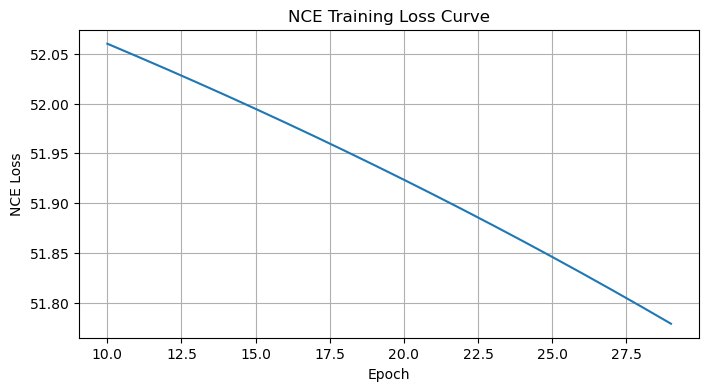

In [7]:
## TESTING THE IMPLEMENTATION
if __name__ == "__main__":
    baskets = []
    baskets_count = 0
    while baskets_count < N_BASKET:
        first_item, first_nest = select_first_item()
        basket = complete_basket(first_item, first_nest)
        basket = add_noise(basket)
        if len(basket) > 3:
            baskets_count += 1
            baskets.append(basket)
    print(f"Generated {len(baskets)} baskets with items from {ASSORTMENT}.\n")

    

    
    print("Initializing weights ... \n")
    init_weights()

    print("Creating (context, target_item) pairs from synthetic baskets ... \n")
    baskets_TI = []
    for i in range(N_BASKET):
        basket_items = baskets[i] 
        target_item = random.choice(basket_items)
        context = Context(Basket(Wi, Wo, basket_items = basket_items, n_items = I, embedding_dim = K, n_items_basket = DEFAULT_N_ITEMS_BASKET), wa=wa, target_item=target_item)
        #context._context_embed()
        baskets_TI.append((context, target_item))

    """
    print("Dataset illustration before training: \n")

    for basket, target_item in baskets_TI[:5]:
        context_items = set(basket.context_items.numpy())
        scores = np.array([basket.score(i) for i in range(I)])
        for i in context_items:
            scores[i] = -np.inf
        most_relevant = np.argmax(scores)
        print(basket, 'Target item:', target_item, 'Predicted item:', most_relevant)
    

    print("\n")
    print("Pre-training accuracy:", accuracy(baskets_TI), '\n')
    """

    print("Training the model ... \n")
    trainer = Trainer(baskets_TI, (Wi, wa, Wo), lr=L_R, K_noise=K_NOISE, epochs=TRAINING_EPOCHS)
    loss_history = trainer.fit()


    print("\n")
    print("Dataset illustration before training: \n")

    for basket, target_item in baskets_TI[:5]:
        context_items = set(basket.context_items.numpy())
        scores = np.array([basket.score(i) for i in range(I)])
        for i in context_items:
            scores[i] = -np.inf
        most_relevant = np.argmax(scores)
        print(basket, 'Target item:', target_item, 'Predicted item:', most_relevant)
    
    print("\n")
    print("post-training accuracy:", accuracy(baskets_TI), '\n')


    print("Plotting training loss curve ... \n")
    plt.figure(figsize=(8, 4))
    plt.plot(loss_history)
    plt.xlabel('Epoch')
    plt.ylabel('NCE Loss')
    plt.title('NCE Training Loss Curve')
    plt.grid(True)
    plt.show()


Getting P(i|j)

context items =[1 5 6] Target item: 7
context items =[2 6] Target item: 5
context items =[7] Target item: 6
context items =[1] Target item: 0
context items =[3] Target item: 7
context items =[0 3] Target item: 6

Training the model ... 



Training epochs: 100%|██████████| 20/20 [00:55<00:00,  2.77s/it]

Wi changed: True
wa changed: True
Wo changed: True
context items =[1 5 6] Target item: 7 Predicted item: 4
context items =[2 6] Target item: 5 Predicted item: 1
context items =[7] Target item: 6 Predicted item: 6
context items =[1] Target item: 0 Predicted item: 2
context items =[3] Target item: 7 Predicted item: 7
Training completed, plotting training loss curve ... 



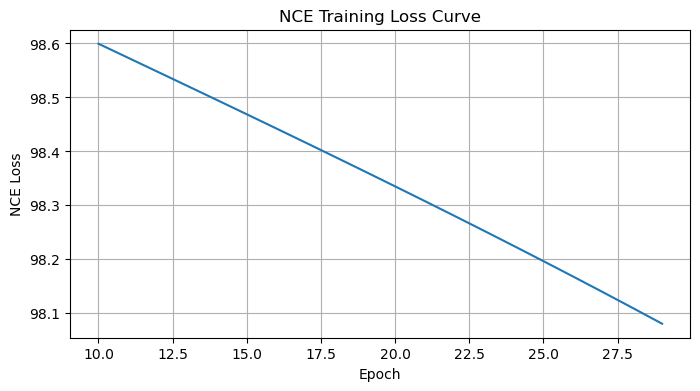

Calculating P(i|j) for all items ... 


P(i|j) matrix before normalization:
 [[ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 8.  0.  7.  1. 14.  0. 23. 11.]
 [ 0.  8.  0.  2.  0.  1.  3.  5.]
 [ 0.  1.  1.  0.  0.  1.  0.  1.]
 [13.  0.  3.  7.  0. 20.  7.  6.]
 [ 0.  1.  1.  0.  1.  0.  0.  0.]
 [ 0.  0.  4.  1.  1.  0.  0. 16.]
 [ 0.  0.  7.  4.  0.  0.  0.  0.]]

P(i|j) matrix:
 [[0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.381 0.    0.304 0.067 0.875 0.    0.697 0.282]
 [0.    0.8   0.    0.133 0.    0.045 0.091 0.128]
 [0.    0.1   0.043 0.    0.    0.045 0.    0.026]
 [0.619 0.    0.13  0.467 0.    0.909 0.212 0.154]
 [0.    0.1   0.043 0.    0.062 0.    0.    0.   ]
 [0.    0.    0.174 0.067 0.062 0.    0.    0.41 ]
 [0.    0.    0.304 0.267 0.    0.    0.    0.   ]]


In [9]:
print("Getting P(i|j)\n")

init_weights()
N_SAMPLES = 30

count = 0
baskets_TI = []

while count <= N_SAMPLES:
    first_item, first_nest = select_first_item()
    basket = complete_basket(first_item, first_nest)
    basket = add_noise(basket)
    basket = list(basket)
    if len(basket) < 2:
        continue
    x = random.choice(basket)
    context = Context(Basket(Wi, Wo, basket_items = basket, n_items = I, embedding_dim = K, n_items_basket = DEFAULT_N_ITEMS_BASKET), wa=wa, target_item = x)
    baskets_TI.append((context, x))
    count += 1

for i in range(6):
    print(baskets_TI[i][0], 'Target item:', baskets_TI[i][1])

Wi_init = Wi.numpy().copy()
wa_init = wa.numpy().copy()
Wo_init = Wo.numpy().copy()

print("\nTraining the model ... \n")
trainer = Trainer(baskets_TI, (Wi, wa, Wo), lr=L_R, K_noise=K_NOISE, epochs=TRAINING_EPOCHS)
loss_history = trainer.fit()

print("Wi changed:", not np.allclose(Wi.numpy(), Wi_init))
print("wa changed:", not np.allclose(wa.numpy(), wa_init))
print("Wo changed:", not np.allclose(Wo.numpy(), Wo_init))

for basket, target_item in baskets_TI[:5]:
        context_items = set(basket.context_items.numpy())
        scores = np.array([basket.score(i) for i in range(I)])
        for i in context_items:
            scores[i] = -np.inf
        most_relevant = np.argmax(scores)
        print(basket, 'Target item:', target_item, 'Predicted item:', most_relevant)

print("Training completed, plotting training loss curve ... \n")

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('NCE Loss')
plt.title('NCE Training Loss Curve')
plt.grid(True)
plt.show()


print("Calculating P(i|j) for all items ... \n")
P_ij = np.zeros((I, I))

N_SAMPLES = 100
contexts = []
count  = 0


while count <= N_SAMPLES:
    first_item, first_nest = select_first_item()
    basket = complete_basket(first_item, first_nest)
    basket = add_noise(basket)
    basket = list(basket)
    if len(basket) < 2:
        continue
    context = Context(Basket(Wi, Wo, basket_items = basket, n_items = I, embedding_dim = K, n_items_basket = DEFAULT_N_ITEMS_BASKET), wa=wa)
    contexts.append(context)
    count += 1





for context in contexts:
    most_relevant = context.most_relevant()
    for j in context.context_items.numpy():
        P_ij[most_relevant, j] += 1

print("\nP(i|j) matrix before normalization:\n", P_ij)

P_ij /= np.sum(P_ij, axis=0, keepdims=True)
np.set_printoptions(precision=3, suppress=True)
print("\nP(i|j) matrix:\n", P_ij)